# Spatial Domain Detection

Spatial domain detection identifies contiguous tissue regions with distinct molecular profiles. Unlike standard clustering (which ignores space), spatial clustering ensures that spots in the same cluster are spatially close.

We'll compare standard Leiden clustering with spatially-constrained clustering.

In [15]:
!pip install scanpy scikit-misc pot leidenalg

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/STAGATE-1.0.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 35.9 MB/s eta 0:00:00


In [13]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.sparse import issparse

# Spatial transcriptomics libraries
import scanpy as sc
import anndata as ad
import tensorflow as tf

# Configure settings
warnings.filterwarnings('ignore')
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=False)
sc.logging.print_header()

# Set random seed for reproducibility
np.random.seed(42)

print(f"\nPackage versions:")
print(f"  Scanpy: {sc.__version__}")
print(f"  AnnData: {ad.__version__}")


Package versions:
  Scanpy: 1.12
  AnnData: 0.12.10


In [3]:
# Define color scheme for consistent visualizations
COLORS = {
    'primary': '#2E86AB',      # Blue
    'secondary': '#A23B72',    # Purple
    'tertiary': '#F18F01',     # Orange
    'quaternary': '#C73E1D',   # Red
    'accent1': '#6A994E',      # Green
    'accent2': '#BC4B51',      # Rose
    'light_gray': '#E5E5E5',
    'dark_gray': '#4A4A4A'
}

# Create color palette for clusters (up to 20 colors)
CLUSTER_COLORS = [
    '#E63946', '#F1FAEE', '#A8DADC', '#457B9D', '#1D3557',
    '#F77F00', '#D62828', '#003049', '#669BBC', '#780000',
    '#C1121F', '#FDF0D5', '#003049', '#780116', '#F7B801',
    '#F18701', '#F35B04', '#C1121F', '#669BBC', '#023047'
]

# Matplotlib style configuration
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = False
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("✓ Color scheme and plotting parameters configured")

✓ Color scheme and plotting parameters configured


## 2. Data Loading and Preprocessing

We'll load the adult mouse brain spatial transcriptomics dataset and perform basic preprocessing including:
- Quality control
- Normalization
- Feature selection
- Dimensionality reduction

In [4]:
!pip install gdown
import gdown

url = "https://drive.google.com/uc?id=1lRM-tR1MMbtgyKXLqRzV2YxokweiNUMz"
data_path = "adult_mouse_brain_ST4k.h5ad"
gdown.download(url, data_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1lRM-tR1MMbtgyKXLqRzV2YxokweiNUMz
To: /content/adult_mouse_brain_ST4k.h5ad
100%|██████████| 5.71M/5.71M [00:00<00:00, 33.3MB/s]


'adult_mouse_brain_ST4k.h5ad'

In [5]:
# Load the spatial transcriptomics data
data_path = 'adult_mouse_brain_ST4k.h5ad'
adata = sc.read_h5ad(data_path)

print("\n" + "="*80)
print("DATA OVERVIEW")
print("="*80)
print(f"Number of spots: {adata.n_obs:,}")
print(f"Number of genes: {adata.n_vars:,}")
print(f"\nAnnData object:")
print(adata)

# Check spatial coordinates
if 'spatial' in adata.obsm.keys():
    print(f"\n✓ Spatial coordinates available: {adata.obsm['spatial'].shape}")
else:
    print("\n⚠ Warning: No spatial coordinates found!")


DATA OVERVIEW
Number of spots: 4,000
Number of genes: 20,062

AnnData object:
AnnData object with n_obs × n_vars = 4000 × 20062
    obs: 'n_genes_by_counts'
    var: 'Symbol'
    obsm: 'spatial'

✓ Spatial coordinates available: (4000, 3)


In [6]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

# Preserve raw counts before any normalisation so they can be
# retrieved later (e.g. for Seurat-v3 HVG selection).
adata.layers['counts'] = adata.X.copy()

# --- 1. Library-size normalisation -------------------------------------------
# Scale every spot to 10 000 total counts. This removes the effect of
# variable sequencing depth while preserving relative gene expression.
sc.pp.normalize_total(adata, target_sum=1e4)

# --- 2. Log-transformation ---------------------------------------------------
# log1p(x) = log(x + 1). Compresses the dynamic range, making the
# distribution closer to Gaussian and reducing the influence of outliers.
sc.pp.log1p(adata)

# --- 3. Highly Variable Gene (HVG) selection ---------------------------------
# Retain only the 3 000 most variable genes. This accelerates downstream
# computation and improves signal-to-noise by discarding near-constant genes.
# Seurat-v3 method works on raw counts (stored in layer 'counts').
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    flavor='seurat_v3',
    layer='counts',
)
print(f"Highly variable genes selected: {adata.var['highly_variable'].sum()}")

# --- 4. PCA ------------------------------------------------------------------
# Compute 50 principal components on HVGs only.
# PCA serves as the baseline low-dimensional representation and as input
# for the neighborhood graph used by standard Leiden clustering.
sc.pp.pca(adata, n_comps=50, use_highly_variable=True)

# --- 5. Neighbourhood graph & UMAP (for reference) ---------------------------
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

print("\n✓ Preprocessing complete")
print(f"  PCA embedding: {adata.obsm['X_pca'].shape}")

# Ensure 2-D spatial coordinates
# The dataset stores (x, y, z) or similar; keep only x and y for spatial methods.
if adata.obsm['spatial'].shape[1] > 2:
    adata.obsm['spatial'] = adata.obsm['spatial'][:, :2].astype(float)
    print(f"  Spatial coordinates trimmed to 2D: {adata.obsm['spatial'].shape}")

print(f"\nAnnData after preprocessing:\n{adata}")


Highly variable genes selected: 3000

✓ Preprocessing complete
  PCA embedding: (4000, 50)
  Spatial coordinates trimmed to 2D: (4000, 2)

AnnData after preprocessing:
AnnData object with n_obs × n_vars = 4000 × 20062
    obs: 'n_genes_by_counts'
    var: 'Symbol', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'


## 3. Spatial Domain Detection

We compare two state-of-the-art graph neural network methods for identifying
spatially coherent tissue domains:

| Method | Core idea | Publication |
|--------|-----------|-------------|
| **STAGATE** | Graph ATtention auto-Encoder; learns a low-dimensional embedding that balances gene expression similarity and spatial proximity | *Nature Communications* 2022 |
| **GraphST** | Graph Self-supervised Contrastive learning; joint self-supervised and contrastive objectives encourage spatially consistent representations | *Nature Communications* 2023 |

We evaluate clustering quality with the **Davies-Bouldin (DB) index**:  
$$\text{DB} = \frac{1}{k}\sum_{i=1}^{k}\max_{j\neq i}\frac{s_i + s_j}{d(c_i,c_j)}$$
where $s_i$ is the mean intra-cluster scatter and $d(c_i, c_j)$ is the distance
between cluster centroids. **Lower DB → more compact, well-separated clusters.**


In [9]:
# Install STAGATE from source (https://github.com/zhanglabtools/STAGATE)
# Downloading the repository zip gives a directory named 'STAGATE-main'.
import os, sys, glob, site

if not os.path.isdir('STAGATE-main'):
    !wget -q https://github.com/zhanglabtools/STAGATE/archive/refs/heads/main.zip -O STAGATE.zip
    !unzip -q STAGATE.zip
    print("✓ STAGATE repository downloaded and unpacked")
else:
    print("✓ STAGATE-main directory already exists, skipping download")

%cd STAGATE-main
!python setup.py build
!python setup.py install
%cd ..

# setup.py installs as an .egg; Colab's kernel does not always auto-discover
# newly created eggs. Add all STAGATE eggs to sys.path explicitly.
for _egg in glob.glob(os.path.join(site.getsitepackages()[0], 'STAGATE*.egg')):
    if _egg not in sys.path:
        sys.path.insert(0, _egg)
        print(f"  Added to sys.path: {_egg}")

# Install GraphST (Graph Self-supervised Contrastive learning for ST)
!pip install GraphST -q

print("\n✓ Packages installed")
import STAGATE
from GraphST import GraphST
from GraphST.utils import clustering as graphst_clustering
print(f"  STAGATE {STAGATE.__version__ if hasattr(STAGATE, '__version__') else 'imported'}")
print(f"  GraphST imported")


✓ STAGATE-main directory already exists, skipping download
/content/STAGATE-main
running build
running build_py
running egg_info
writing STAGATE.egg-info/PKG-INFO
writing dependency_links to STAGATE.egg-info/dependency_links.txt
writing requirements to STAGATE.egg-info/requires.txt
writing top-level names to STAGATE.egg-info/top_level.txt
reading manifest file 'STAGATE.egg-info/SOURCES.txt'
adding license file 'LICENSE'
writing manifest file 'STAGATE.egg-info/SOURCES.txt'
running install
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ***************************************

### 3.1 STAGATE — Graph Attention Auto-Encoder

STAGATE constructs a **spatial neighbor graph** (spots within a radius cutoff
are connected) and trains a **graph attention auto-encoder** that:
1. Encodes gene expression into a compact latent vector.
2. Uses attention weights to down-weight dissimilar neighbours, so domain
   boundaries are preserved.
3. Reconstructs gene expression from the latent space (self-supervised signal).

The resulting `adata.obsm['STAGATE']` embedding is then clustered with the
Leiden algorithm.


In [ ]:
import STAGATE
import torch

# ── Step 1: Build spatial neighbourhood graph ──────────────────────────────
# rad_cutoff: Euclidean distance threshold in the coordinate unit.
# Spots within this radius become graph edges.
# Strategy: set cutoff to ≈1.5× the median nearest-neighbour distance so
# each spot has ~6 neighbours on average (similar to Visium hexagonal grid).
from scipy.spatial.distance import cdist

coords = adata.obsm['spatial']
sample_idx = np.random.choice(adata.n_obs, min(200, adata.n_obs), replace=False)
sample_dists = cdist(coords[sample_idx], coords[sample_idx])
np.fill_diagonal(sample_dists, np.inf)
rad_cutoff = float(np.median(sample_dists.min(axis=1)) * 1.5)
print(f"Auto-estimated rad_cutoff: {rad_cutoff:.1f}")

STAGATE.Cal_Spatial_Net(adata, rad_cutoff=rad_cutoff)
STAGATE.Stats_Spatial_Net(adata)  # prints graph statistics

# ── Step 2: Train the graph attention auto-encoder ─────────────────────────
# hidden_dims: encoder layer sizes; the last value is the latent dimension.
#   [512, 30] → input genes → 512 hidden → 30-dim latent space
# n_epochs: 1000 iterations typically achieves convergence.
# device: switch to 'cuda' if a GPU is available for ~10× speed-up.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\nTraining STAGATE on device: {device}")
tf.compat.v1.disable_eager_execution()
adata = STAGATE.train_STAGATE(
    adata,
    hidden_dims=[512, 30],   # encoder architecture
    n_epochs=1000,
    lr=0.001,
    weight_decay=1e-4,
    # device=device,
)
# adata.obsm['STAGATE'] now contains the 30-dimensional spatial-aware embeddings
print(f"\nSTAGATE embedding stored in adata.obsm['STAGATE']: {adata.obsm['STAGATE'].shape}")



In [17]:
# ── Step 3: Cluster the STAGATE embeddings ──────────────────────────────────
# Build a KNN graph in the STAGATE latent space (separate from the PCA graph).
sc.pp.neighbors(adata, use_rep='STAGATE', key_added='stagate_neighbors', n_neighbors=15)
sc.tl.leiden(
    adata,
    neighbors_key='stagate_neighbors',
    key_added='stagate_domain',
    resolution=0.05,      # controls granularity; increase for more clusters
    random_state=42,
)

n_stagate = adata.obs['stagate_domain'].nunique()
print(f"\n✓ STAGATE: {n_stagate} spatial domains identified")
print(adata.obs['stagate_domain'].value_counts().rename('spot count').to_string())



✓ STAGATE: 5 spatial domains identified
stagate_domain
0    2415
1     763
2     310
3     285
4     227


### 3.2 GraphST — Graph Self-supervised Contrastive Learning

GraphST jointly optimises three objectives:
1. **Reconstruction** — reconstruct masked gene expression.
2. **Self-supervised contrastive** — augment the spatial graph with random
   masking; pull together augmented views of the same spot.
3. **Spatial contrastive** — spots with similar expression profiles but
   distant spatial positions are pushed apart.

The 64-dimensional output embedding (`adata.obsm['emb']`) is then clustered
with mclust (a Gaussian mixture model), with a spatial refinement step that
smooths boundaries by reassigning spots whose expression is more similar to
an adjacent domain.


In [21]:
from GraphST import GraphST as GraphST_module
from GraphST.utils import clustering as graphst_clustering
import torch

# Number of spatial domains to identify.
# For adult mouse brain, 7 domains (cortical layers + white matter + other
# major regions) is a commonly used starting point.
N_CLUSTERS = 4

# ── Step 1: Initialise and train GraphST ────────────────────────────────────
# GraphST internally builds a spatial KNN graph (default k=3) combined with
# an expression-similarity graph. The model optimises three combined losses:
#   (a) gene-expression reconstruction,
#   (b) self-supervised contrastive (masked views),
#   (c) spatial-neighbour contrastive.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Training GraphST on device: {device}")

model = GraphST_module.GraphST(
    adata,
    device=device,
    random_seed=42,
    learning_rate=0.001,
    weight_decay=0.00,
    epochs=300,           # 600 epochs are sufficient for convergence
)

# Training stores the 64-dim embeddings in adata.obsm['emb']
# and a preliminary cluster assignment in adata.obs['domain'].
adata = model.train()
print(f"\nGraphST embedding stored in adata.obsm['emb']: {adata.obsm['emb'].shape}")

# ── Step 2: Cluster with mclust + spatial refinement ────────────────────────
# mclust fits a Gaussian mixture model to the embedding space, which often
# yields more natural cluster shapes than k-means.
# refinement=True iteratively reassigns boundary spots based on their
# spatial neighbourhood — sharpening domain edges.
try:
    graphst_clustering(
        adata,
        n_clusters=N_CLUSTERS,
        radius=50,
        method='mclust',
        refinement=True,
    )
    adata.obs['graphst_domain'] = adata.obs['domain'].copy()
    print("  Clustering method: mclust with spatial refinement")
except Exception as e:
    # mclust requires R + rpy2. Fall back to Leiden if unavailable.
    print(f"  mclust unavailable ({e}); falling back to Leiden clustering")
    sc.pp.neighbors(adata, use_rep='emb', key_added='graphst_neighbors', n_neighbors=15)
    sc.tl.leiden(
        adata,
        neighbors_key='graphst_neighbors',
        key_added='graphst_domain',
        resolution=0.3,
        random_state=42,
    )
    print("  Clustering method: Leiden (fallback)")

n_graphst = adata.obs['graphst_domain'].nunique()
print(f"\n✓ GraphST: {n_graphst} spatial domains identified")
print(adata.obs['graphst_domain'].value_counts().rename('spot count').to_string())


Training GraphST on device: cpu
Begin to train ST data...


100%|██████████| 300/300 [22:30<00:00,  4.50s/it]


Optimization finished for ST data!

GraphST embedding stored in adata.obsm['emb']: (4000, 3000)


  there is no package called ‘mclust’



  mclust unavailable (Error in (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  : 
  there is no package called ‘mclust’
); falling back to Leiden clustering
  Clustering method: Leiden (fallback)

✓ GraphST: 4 spatial domains identified
graphst_domain
0    1596
1     969
2     766
3     669


### 3.3 Comparison — Davies-Bouldin Index & Spatial Maps

We compute the Davies-Bouldin index **in each method's own embedding space**
(STAGATE latent for STAGATE clusters, GraphST latent for GraphST clusters).
This reflects how well each method's representation captures the cluster
structure it was trained to produce.

> **Interpretation**:  
> A lower DB index means clusters are more compact and better separated in
> the embedding — indicating higher-quality spatial domains.



════════════════════════════════════════════════
  DAVIES-BOULDIN INDEX  (lower = better)
════════════════════════════════════════════════
  STAGATE  : 2.9845
  GraphST  : 2.8253

  → GraphST achieves better cluster separation
════════════════════════════════════════════════


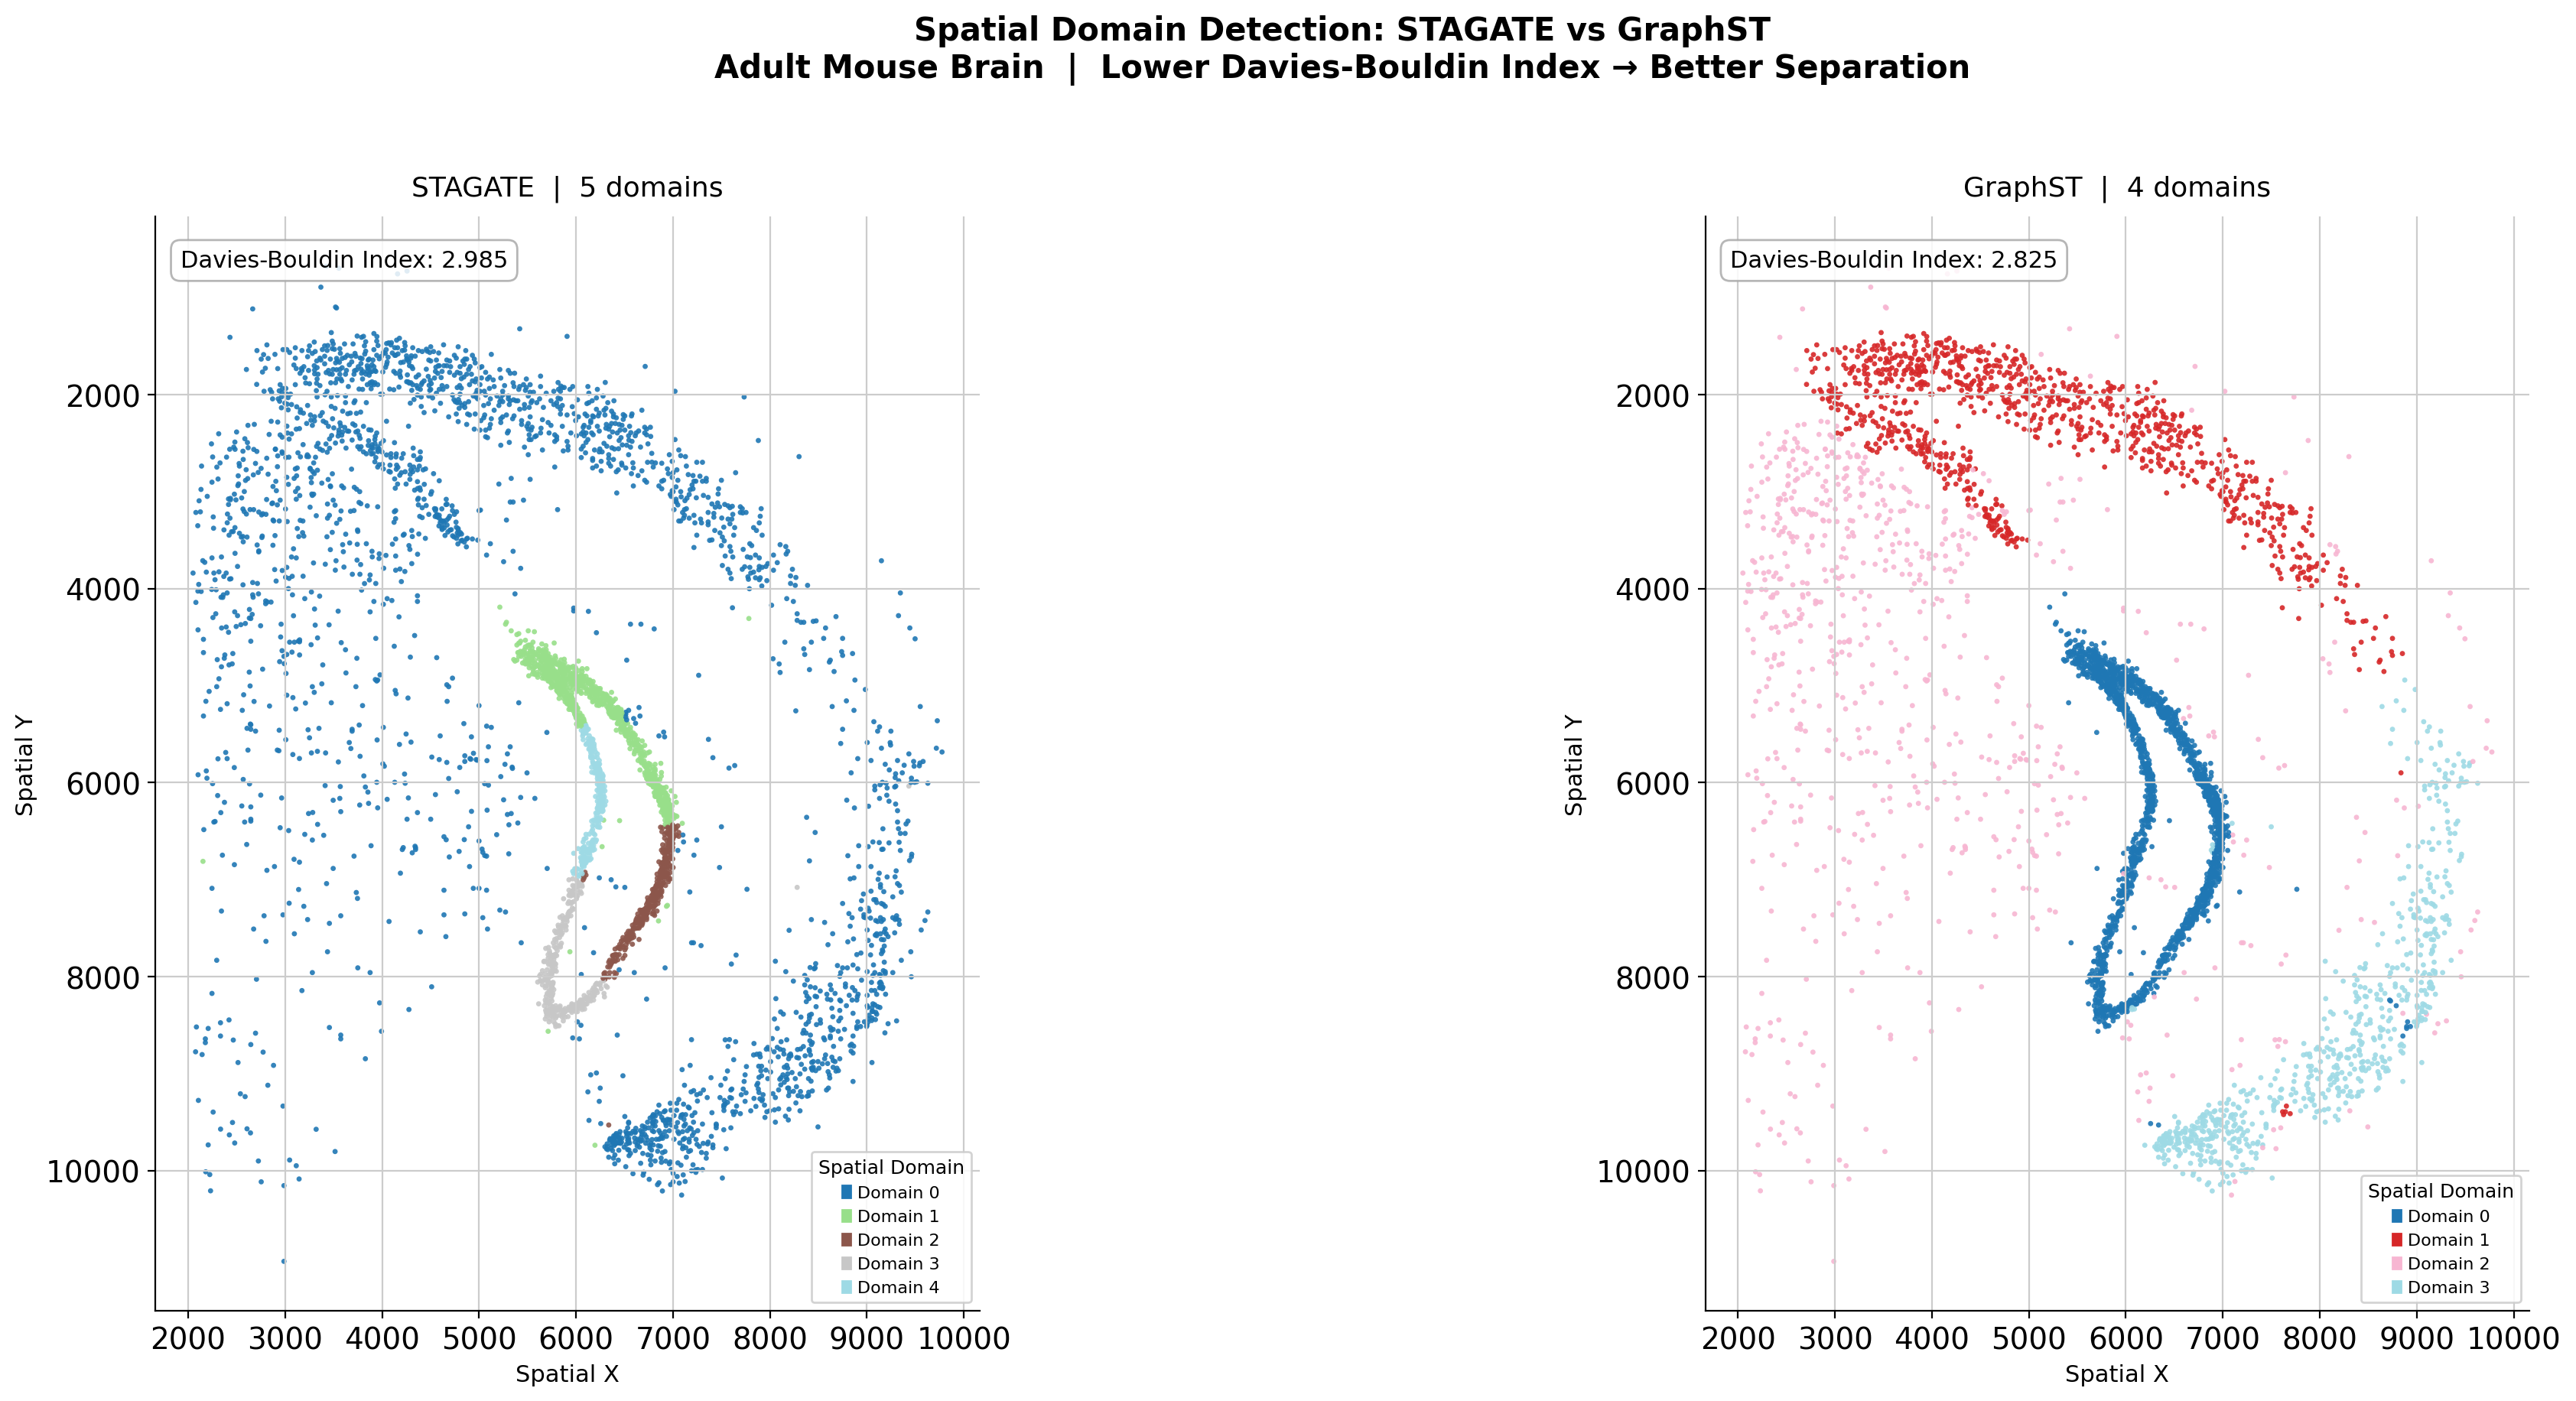


✓ Figure saved as 'spatial_domains_comparison.png'


In [22]:
from sklearn.metrics import davies_bouldin_score
import matplotlib.patches as mpatches

# ── 1. Davies-Bouldin Index ─────────────────────────────────────────────────
# Labels must be integer arrays; convert categorical/string labels.
stagate_int = pd.Categorical(adata.obs['stagate_domain']).codes
graphst_int = pd.Categorical(adata.obs['graphst_domain']).codes

# DB in each method's own latent embedding space.
db_stagate = davies_bouldin_score(adata.obsm['STAGATE'], stagate_int)
db_graphst = davies_bouldin_score(adata.obsm['emb'],     graphst_int)

print("\n" + "═" * 48)
print("  DAVIES-BOULDIN INDEX  (lower = better)")
print("═" * 48)
print(f"  STAGATE  : {db_stagate:.4f}")
print(f"  GraphST  : {db_graphst:.4f}")
winner = 'STAGATE' if db_stagate < db_graphst else 'GraphST'
print(f"\n  → {winner} achieves better cluster separation")
print("═" * 48)

# ── 2. Colour assignments ───────────────────────────────────────────────────
def domain_colors(label_series, cmap_name='tab20'):
    """Return (colors_per_spot, legend_patches) for a categorical label series."""
    categories = sorted(label_series.unique(), key=str)
    cmap = plt.cm.get_cmap(cmap_name, len(categories))
    color_map = {cat: cmap(i) for i, cat in enumerate(categories)}
    colors = [color_map[lbl] for lbl in label_series]
    patches = [
        mpatches.Patch(color=color_map[cat], label=f'Domain {cat}')
        for cat in categories
    ]
    return colors, patches

# Spatial (x, y) coordinates
x = adata.obsm['spatial'][:, 0]
y = adata.obsm['spatial'][:, 1]

# ── 3. Figure: two-panel spatial domain maps ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle(
    'Spatial Domain Detection: STAGATE vs GraphST\n'
    'Adult Mouse Brain  |  Lower Davies-Bouldin Index → Better Separation',
    fontsize=15, fontweight='bold', y=1.02
)

for ax, domain_key, method_name, db_score in [
    (axes[0], 'stagate_domain', 'STAGATE', db_stagate),
    (axes[1], 'graphst_domain', 'GraphST',  db_graphst),
]:
    colors, patches = domain_colors(adata.obs[domain_key])
    n_domains = adata.obs[domain_key].nunique()

    ax.scatter(
        x, y,
        c=colors,
        s=6,
        linewidths=0,
        alpha=0.9,
        rasterized=True,  # speeds up PDF/SVG export for large point clouds
    )

    # DB score annotation box (top-left corner)
    ax.text(
        0.03, 0.97,
        f'Davies-Bouldin Index: {db_score:.3f}',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#aaaaaa'),
    )

    ax.legend(
        handles=patches,
        title='Spatial Domain',
        loc='lower right',
        fontsize=8,
        title_fontsize=9,
        framealpha=0.85,
        markerscale=1.5,
    )

    ax.set_title(
        f'{method_name}  |  {n_domains} domains',
        fontsize=13, pad=10
    )
    ax.set_xlabel('Spatial X', fontsize=11)
    ax.set_ylabel('Spatial Y', fontsize=11)
    ax.set_aspect('equal')
    ax.invert_yaxis()  # match the conventional tissue orientation (origin top-left)

plt.tight_layout()
plt.savefig('spatial_domains_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Figure saved as 'spatial_domains_comparison.png'")
